## **Messwerte**

In [136]:
import numpy as np


c_vol_wasser = 4.19 * 10**6 #Wärmekapazität von Wasser pro Volumen in J / m^3 * K
c_vol_wasser_Fehler = 0


"""-------------------------------------------------------------------------------------"""

T_Fehler_1 = 0.1 #Fehler für die Temperaturmessung

v_wasser_warm_1 = 1 #Menge des zugegebenen warmen Wassers in m^3
v_wasser_warm_1_Fehler = 0

T_wasser_warm_1 = 200 #Temperatur des warmen wassers in Kelvin



T_kalorimeter_warm_1 = np.array([1.1, 1.2, 1.3, 1.4, 1.5, 1.6]) #Messung nach Zugabe des warmen wassers in Kelvin 3 Minuten alle 30 Sekunden

T_Zugabe_1 = None #Temperatur bei der das kalte Wasser zugegeben wird #TODO: Richtig?



v_wasser_kalt_1 = 1 #Menge des zugegebenen kalten Wassers in m^3
v_wasser_kalt_1_Fehler = 0

T_Wasser_kalt_1 = 100 #Temperatur des kalten Wassers



T_kalorimeter_kalt_1 = np.array([1.6, 1.5, 1.4, 1.3, 1.2, 1.1]) #Temperatur nach Zugabe des kalten Wassers in der ersten Minute alle 10 Sekunden

T_kalorimeter_kalt_langfristig_1 = np.array([1.1, 1.2, 1.3, 1.4]) #Temperatur nach Zugabe des kalten Wassers nach einer Minute über 2 Minuten alle 30 Sekunden

T_final_1 = None #Finale Mischtemperatur nach Zugabe des kalten Wassers in Kelvin #TODO: Richtig?


"""------------------------------------------------------------------------------------------------------------------------------------------------------------------"""

T_Fehler_2 = 0.1 #Fehler für die Temperaturmessung

v_wasser_warm_2 = 2 #Menge des zugegebenen warmen Wassers in m^3
v_wasser_warm_2_Fehler = 0

T_wasser_warm_2 = 200 #Temperatur des warmen wassers in Kelvin



T_kalorimeter_warm_2 = np.array([1.1, 1.2, 1.3, 1.4, 1.5, 1.6]) #Messung nach Zugabe des warmen wassers in Kelvin 3 Minuten alle 30 Sekunden

T_Zugabe_2 = None #Temperatur bei der das kalte Wasser zugegeben wird #TODO: Richtig?


v_wasser_kalt_2 = 2 #Menge des zugegebenen kalten Wassers in m^3
v_wasser_kalt_2_Fehler = 0

T_Wasser_kalt_2 = 100 #Temperatur des kalten Wassers



T_kalorimeter_kalt_2 = np.array([1.6, 1.5, 1.4, 1.3, 1.2, 1.1]) #Temperatur nach Zugabe des kalten Wassers in der ersten Minute alle 10 Sekunden

T_kalorimeter_kalt_langfristig_2 = np.array([1.1, 1.2, 1.3, 1.4]) #Temperatur nach Zugabe des kalten Wassers nach einer Minute über 2 Minuten alle 30 Sekunden

T_final_2 = None #Finale Mischtemperatur nach Zugabe des kalten Wassers in Kelvin #TODO: Richtig


## **Plots**

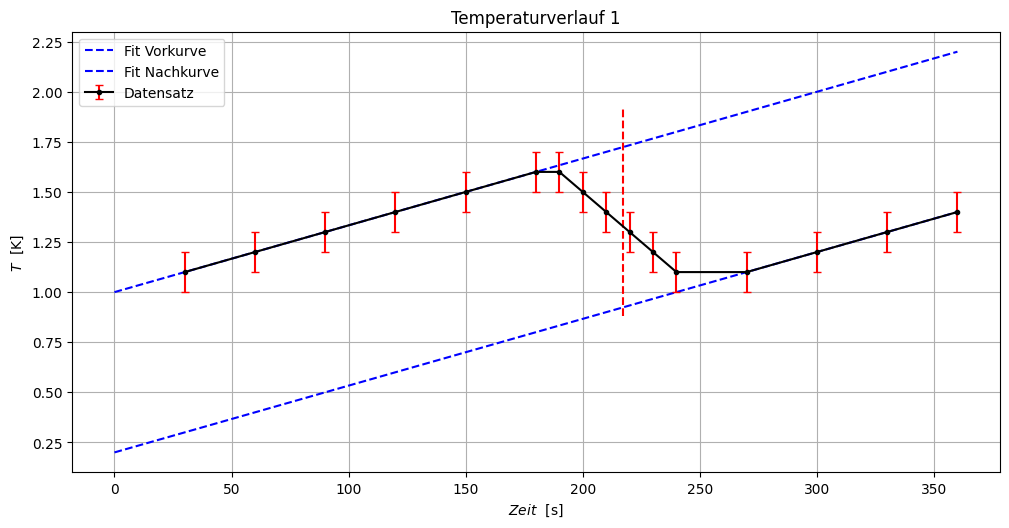

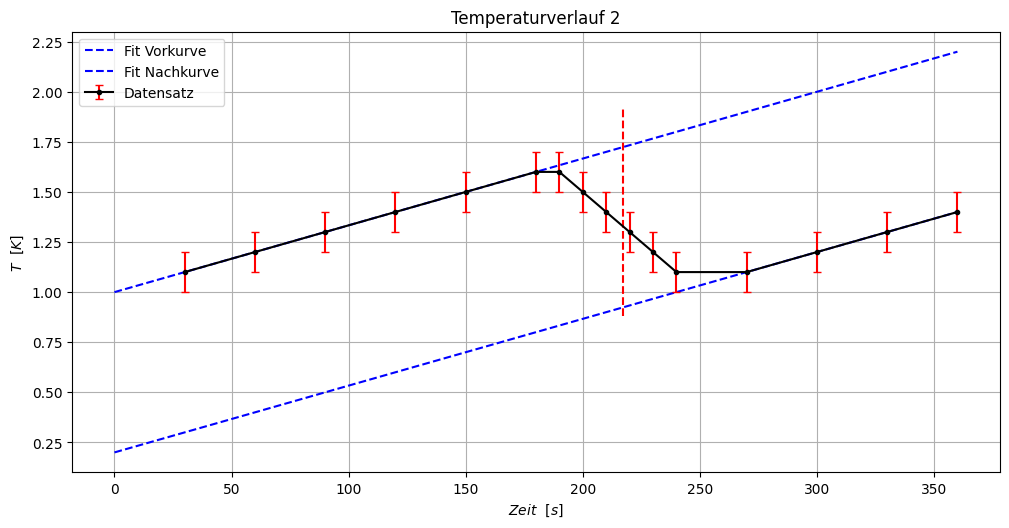

In [137]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import simpson
from scipy.optimize import fsolve
from scipy.integrate import quad

def f(x,k,a):
    return k*x +a

Zeiten = np.array([30, 60, 90, 120, 150, 180, 190, 200, 210, 220, 230, 240, 270, 300, 330, 360]) #Messzeiten in Sekunden

Zeiten_Vorkurve = Zeiten[0:6]
Zeiten_Nachkurve = Zeiten[12:17]
zeiten_hauptkurve = Zeiten[6:12]

t_Ende_Vorkurve = 180
t_Anfang_Nachkurve = 240

A_messung_1 = simpson(y=T_kalorimeter_kalt_1, x=zeiten_hauptkurve)
A_messung_2 = simpson(y=T_kalorimeter_kalt_2, x=zeiten_hauptkurve)

xwerte = np.linspace(0, 360, 1000)

def Dreiecksflaechen(xval, vork, nachk, A_messung):
    xval = xval[0] if isinstance(xval, (list, np.ndarray)) else xval

    if xval >= t_Anfang_Nachkurve or xval <= t_Ende_Vorkurve:
        return 100e6

    A1, _ = quad(vork, zeiten_hauptkurve[0], xval)
    A2, _ = quad(nachk, xval, zeiten_hauptkurve[-1])

    A_theorie = A1 + A2

    return A_theorie - A_messung

fig, ax1 = plt.subplots(1,1, figsize = (10,5))
fig.tight_layout()

"""----------------------------------------------------------------------------------------------------------------------------------------------------------"""

#Lineare Fits für Vor- und Nachkurve

coeficcients_1V, pcov = curve_fit(f, Zeiten_Vorkurve, T_kalorimeter_warm_1, sigma=T_Fehler_1, absolute_sigma=True)

def Vorkurve1(x):
    return coeficcients_1V[0]*x + coeficcients_1V[1]

ax1.plot(xwerte, Vorkurve1(xwerte), "b--", label = "Fit Vorkurve")


coeficcients_1N, pcov = curve_fit(f, Zeiten_Nachkurve, T_kalorimeter_kalt_langfristig_1, sigma=T_Fehler_1, absolute_sigma=True)

def Nachkurve1(x):
    return coeficcients_1N[0]*x + coeficcients_1N[1]

ax1.plot(xwerte,Nachkurve1(xwerte), "b--", label = "Fit Nachkurve")

"""---------------------------------------------------------------------------------------------------------------------------------------------------------------"""
#Temperaturen mit dem Zwickelabgleich finden

h_1 = fsolve(Dreiecksflaechen, np.median(Zeiten[6:12]) , args = (Vorkurve1, Nachkurve1, A_messung_1))[0]
ax1.vlines(h_1, ymin=np.min(T_kalorimeter_kalt_1)*0.8, ymax=np.max(T_kalorimeter_warm_1)*1.2, color = "red", linestyle = "dashed")

T_Zugabe_1 = Vorkurve1(h_1)
T_final_1 = Nachkurve1(h_1)

ax1.errorbar(Zeiten, np.concatenate((T_kalorimeter_warm_1, T_kalorimeter_kalt_1, T_kalorimeter_kalt_langfristig_1) ,axis=0), yerr = T_Fehler_1, fmt = "o-", label = "Datensatz", color = "black", markersize  = 3 , capsize = 3, ecolor = "r")

#ax1.hlines(T_final_1, xmin = 0, xmax = 360, color = "orange", linestyles= "dashed", label = "Finale Mischtemperatur")

#ax1.hlines(T_Zugabe_1, xmin = 0, xmax = 360, color = "purple", linestyles= "dashed", label = "Temperatur Zugabe kaltes Wasser")

ax1.set_xlabel("$Zeit~~[\\mathrm{s}]$")
ax1.set_ylabel("$T~~[\\mathrm{K}]$")
ax1.grid(True)
ax1.set_title("Temperaturverlauf 1")
ax1.legend()


"""---------------------------------------------------------------------------------------------------------------------------------------------------------------"""
fig, ax2 = plt.subplots(1,1, figsize = (10,5))
fig.tight_layout()

#Lineare Fits für Vor- und Nachkurve

coeficcients_2V, pcov = curve_fit(f, Zeiten_Vorkurve, T_kalorimeter_warm_2, sigma=T_Fehler_2, absolute_sigma=True)

def Vorkurve2(x):
    return coeficcients_2V[0]*x + coeficcients_2V[1]

ax2.plot(xwerte, Vorkurve2(xwerte), "b--", label = "Fit Vorkurve")


coeficcients_2N, pcov = curve_fit(f, Zeiten_Nachkurve, T_kalorimeter_kalt_langfristig_2, sigma=T_Fehler_2, absolute_sigma=True)

def Nachkurve2(x):
    return coeficcients_2N[0]*x + coeficcients_2N[1]

ax2.plot(xwerte,Nachkurve2(xwerte), "b--", label = "Fit Nachkurve")

"""---------------------------------------------------------------------------------------------------------------------------------------------------------------"""
#Temperaturen mit dem Zwickelabgleich finden

h_2 = fsolve(Dreiecksflaechen, np.median(Zeiten[6:12]) , args = (Vorkurve2, Nachkurve2, A_messung_2))[0]
ax2.vlines(h_2, ymin=np.min(T_kalorimeter_kalt_2)*0.8, ymax=np.max(T_kalorimeter_warm_2)*1.2, color = "red", linestyle = "dashed")

T_Zugabe_2 = Vorkurve2(h_2)
T_final_2 = Nachkurve2(h_2)


ax2.errorbar(Zeiten, np.concatenate((T_kalorimeter_warm_2, T_kalorimeter_kalt_2, T_kalorimeter_kalt_langfristig_2) ,axis=0), yerr = T_Fehler_2, fmt = "o-", label = "Datensatz", color = "black", markersize  = 3 , capsize = 3, ecolor = "r")

#ax2.hlines(T_final_2, xmin = 0, xmax = 360, color = "orange", linestyles= "dashed", label = "Finale Mischtemperatur")

#ax2.hlines(T_Zugabe_2, xmin = 0, xmax = 360, color = "purple", linestyles= "dashed", label = "Temperatur Zugabe kaltes Wasser")

ax2.set_xlabel("$Zeit~~[s]$")
ax2.set_ylabel("$T~~[K]$")
ax2.grid(True)
ax2.set_title("Temperaturverlauf 2")
ax2.legend()


## **Berechnung der Wärmekapazität**

In [138]:
from Skripte.Fehlerfortpflanzung import Gaußfehler
import sympy
from IPython.display import display

C_kalorimeter_1 = (v_wasser_kalt_1*c_vol_wasser*(T_final_1 - T_Wasser_kalt_1) - v_wasser_warm_1*c_vol_wasser*(T_Zugabe_1 - T_final_1)) / (T_Zugabe_1 - T_final_1)

Vkw, cw, Tf, Tk, Vww, Tz = sympy.symbols("V_kalt, c_w, T_final, T_kalt, V_warm, T_Zugabe")

expr1 = (Vkw*cw*(Tf - Tk) - Vww*cw*(Tz - Tf)) / (Tz - Tf)
display(expr1)

Variablen = np.array([Vkw, cw, Tf, Tk, Vww, Tz])
Mittelwerte_1 = np.array([v_wasser_kalt_1, c_vol_wasser, T_final_1, T_Wasser_kalt_1, v_wasser_warm_1, T_Zugabe_1])
Fehler_1 = np.array([v_wasser_kalt_1_Fehler, c_vol_wasser_Fehler, T_Fehler_1, T_Fehler_1, v_wasser_warm_1_Fehler, T_Fehler_1])

C_kalorimeter_1_Fehler = Gaußfehler(expr1, Variablen, Mittelwerte_1, Fehler_1)

"""------------------------------------------------------------------------------------"""

C_kalorimeter_2 = (v_wasser_kalt_2*c_vol_wasser*(T_final_2 - T_Wasser_kalt_2) - v_wasser_warm_2*c_vol_wasser*(T_Zugabe_2 - T_final_2)) / (T_Zugabe_2 - T_final_2)


Mittelwerte_2 = np.array([v_wasser_kalt_2, c_vol_wasser, T_final_2, T_Wasser_kalt_2, v_wasser_warm_2, T_Zugabe_2])
Fehler_2 = np.array([v_wasser_kalt_2_Fehler, c_vol_wasser_Fehler, T_Fehler_2, T_Fehler_2, v_wasser_warm_2_Fehler, T_Fehler_2])

C_kalorimeter_2_Fehler = Gaußfehler(expr1, Variablen, Mittelwerte_2, Fehler_2)

print(f"Wärmekapazität des Aufbaus(1): C = {C_kalorimeter_1} +/- {C_kalorimeter_1_Fehler} J/K")
print(f"Wärmekapazität des Aufbaus(2): C = {C_kalorimeter_2} +/- {C_kalorimeter_2_Fehler} J/K ")

(V_kalt*c_w*(T_final - T_kalt) - V_warm*c_w*(T_Zugabe - T_final))/(T_Zugabe - T_final)

Wärmekapazität des Aufbaus(1): C = -523102586.8055557 +/- 91363556.92823422 J/K
Wärmekapazität des Aufbaus(2): C = -1046205173.6111114 +/- 182727113.85646844 J/K 
